# **Digit Recognizer | CNN | Keras | Beginner**

# 1. Importing required Libraries:

In [1]:
#importing libraries..
import numpy as np 
import pandas as pd 
from sklearn.model_selection import train_test_split
import keras
from keras.utils import np_utils
import tensorflow as tf
import seaborn as sns

In [2]:
np.random.seed(9)
tf.random.set_seed(9)

# 2.1 Loading Training Data and Preprocessing:

In [3]:
#loading train_data
train_data = pd.read_csv("/kaggle/input/digit-recognizer/train.csv") #(42000, 785)
train_data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
#slicing train_data into train_labels and train_images
train_labels = train_data.iloc[:,0].astype(np.float32).values   #(42000, 1) <class 'numpy.ndarray'>
train_images = train_data.iloc[:,1:].astype(np.float32).values   #(42000, 784) <class 'numpy.ndarray'>

#reshaping train_images
train_images = train_images.reshape(42000, 28, 28, 1)   #(42000, 28, 28, 1)  

# 2.1.1 Splitting Training Data into Train and Dev sets:

In [5]:
#splitting train_data into train and dev sets
x_train, x_test, y_train, y_test = train_test_split(train_images, train_labels, test_size=0.024, random_state = 42, shuffle=True, stratify=train_labels)
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape )

(40992, 28, 28, 1) (1008, 28, 28, 1) (40992,) (1008,)


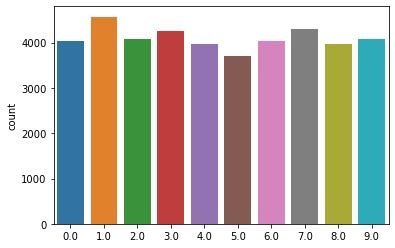

In [6]:
train_set_plot = sns.countplot(y_train)

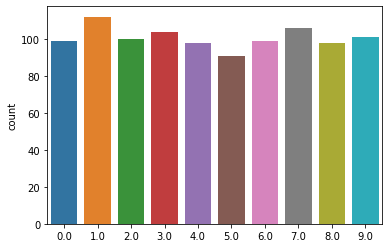

In [7]:
dev_set_plot = sns.countplot(y_test)

In [8]:
#one-hot enoding 
y_train = np_utils.to_categorical(y_train, 10)  
y_test = np_utils.to_categorical(y_test, 10)   

#normalizing train and dev set images
x_train = x_train / 255.0  
x_test = x_test / 255.0

# 2.2 Loading Test Data and Preprocessing:

In [9]:
#loading test_data
test_data = pd.read_csv("/kaggle/input/digit-recognizer/test.csv")  #(28000, 784)
test_data.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
test_images = test_data.astype(np.float32).values # (28000, 784) <class 'numpy.ndarray'>

#reshaping test_images
test_images = test_images.reshape(28000, 28, 28, 1) #(28000, 28, 28, 1)

#normalizing test_images
test_images = test_images / 255.0

# 3. CNN Model

In [11]:
#Model

model = tf.keras.models.Sequential([
  tf.keras.layers.Conv2D(32, (5,5), activation='relu', padding = 'Same', input_shape=(28, 28, 1)),
  tf.keras.layers.MaxPooling2D(2, 2),
  tf.keras.layers.Conv2D(32, (3,3), activation='relu',padding = 'Same'),
  tf.keras.layers.MaxPooling2D(2,2),
  tf.keras.layers.Conv2D(64, (3,3), activation='relu',padding = 'Same'),
  tf.keras.layers.MaxPooling2D(2,2),
  tf.keras.layers.Conv2D(128, (3,3), activation='relu',padding = 'Same'),
  tf.keras.layers.MaxPooling2D(2,2),
  tf.keras.layers.Dropout(0.25),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 28, 28, 32)        832       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 14, 14, 32)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 14, 14, 32)        9248      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 7, 7, 32)          0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 7, 7, 64)          18496     
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 3, 3, 64)          0         
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 3, 3, 128)         7

# 4. Training and Evaluation:

In [12]:
#training model using train set
model.fit(x_train, y_train, epochs=30)

Epoch 1/30
1281/1281 [==============================] - 31s 24ms/step - loss: 0.2276 - accuracy: 0.9277
Epoch 2/30
1281/1281 [==============================] - 31s 25ms/step - loss: 0.0676 - accuracy: 0.9802
Epoch 3/30
1281/1281 [==============================] - 31s 24ms/step - loss: 0.0507 - accuracy: 0.9848
Epoch 4/30
1281/1281 [==============================] - 31s 24ms/step - loss: 0.0406 - accuracy: 0.9881
Epoch 5/30
1281/1281 [==============================] - 32s 25ms/step - loss: 0.0328 - accuracy: 0.9904
Epoch 6/30
1281/1281 [==============================] - 32s 25ms/step - loss: 0.0293 - accuracy: 0.9911
Epoch 7/30
1281/1281 [==============================] - 31s 24ms/step - loss: 0.0257 - accuracy: 0.9922
Epoch 8/30
1281/1281 [==============================] - 31s 24ms/step - loss: 0.0222 - accuracy: 0.9931
Epoch 9/30
1281/1281 [==============================] - 30s 23ms/step - loss: 0.0193 - accuracy: 0.9940
Epoch 10/30
1281/1281 [==============================] - 31s 24m

In [13]:
#evaluating model using dev set
test_loss = model.evaluate(x_test, y_test)

32/32 [==============================] - 0s 8ms/step - loss: 0.0337 - accuracy: 0.9911


# 5. Prediction and Submission File:

In [14]:
#making predictions using test_images
predictions = model.predict(test_images)
predictions = np.argmax(predictions, axis=1)

In [15]:
#making submission file

predictions = pd.Series(predictions,name="Label")
result = pd.concat([pd.Series(range(1,28001),name = "ImageId"),predictions],axis = 1)

result.to_csv("digit_recognizer.csv",index=False)